# **SISTEMAS DE  VISION 317**
# **PRÁCTICA #3: Umbralización y Segmentación de Imágenes con OpenCV.**
**Jose Antonio Martinez Calan 2127803**

IMPORTAR LIBRERÍAS

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

FUNCIÓN PARA MOSTRAR IMÁGENES

In [4]:
def show_image(img, title="Imagen"):
    """
    Función para mostrar imágenes con Matplotlib
    """
    plt.figure(figsize=(6, 4))
    plt.imshow(img, cmap="gray")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

CARGAR Y PREPARAR LA IMAGEN

In [5]:
print(" CARGANDO FOTO")
image = cv2.imread("Foto (1).jpeg")

 CARGANDO FOTO


Convertir a escala de grises

📊 Dimensiones: (1600, 1301)
📈 Rango de intensidades: [0, 253]


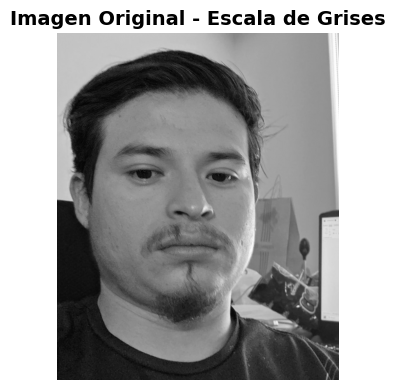

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print(f"📊 Dimensiones: {gray.shape}")
print(f"📈 Rango de intensidades: [{gray.min()}, {gray.max()}]")
#Mostrar imagen original en grises
show_image(gray, "Imagen Original - Escala de Grises")

UMBRALIZACIÓN GLOBAL



 UMBRALIZACIÓN 


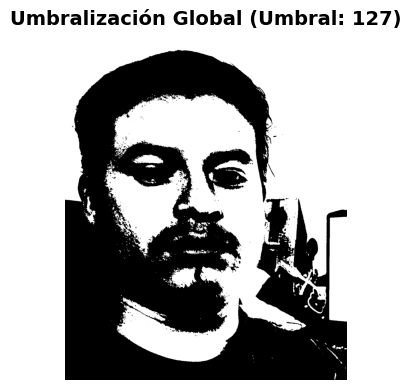

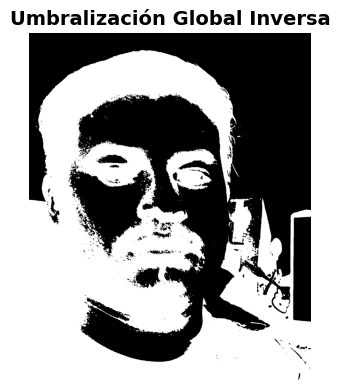

In [7]:
print("\n UMBRALIZACIÓN ")
# Umbralización binaria
_, thresh_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
show_image(thresh_global, "Umbralización Global (Umbral: 127)")
# Umbralización inversa
_, thresh_inv = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
show_image(thresh_inv, "Umbralización Global Inversa")

UMBRALIZACIÓN ADAPTATIVA


 UMBRALIZACIÓN ADAPTATIVA


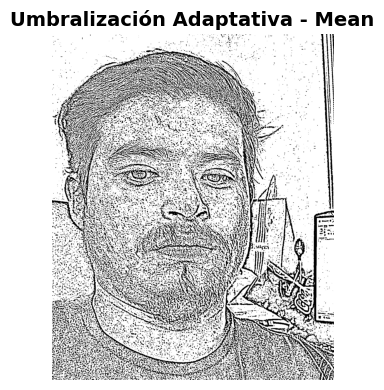

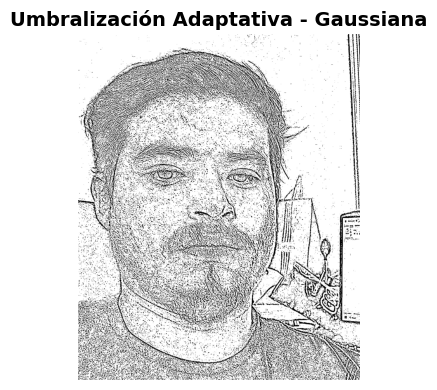

In [8]:
print("\n UMBRALIZACIÓN ADAPTATIVA")
# Método MEAN (Promedio)
thresh_adapt_mean = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,  # Tamaño del bloque (debe ser impar)
    2    # Constante a restar
)
show_image(thresh_adapt_mean, "Umbralización Adaptativa - Mean")

# Método GAUSSIANO
thresh_adapt_gauss = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,  # Tamaño del bloque
    2    # Constante a restar
)
show_image(thresh_adapt_gauss, "Umbralización Adaptativa - Gaussiana")

UMBRALIZACIÓN CON MÉTODO DE OTSU


 UMBRALIZACIÓN CON MÉTODO DE OTSU 
Umbral automático calculado por Otsu: 95.0


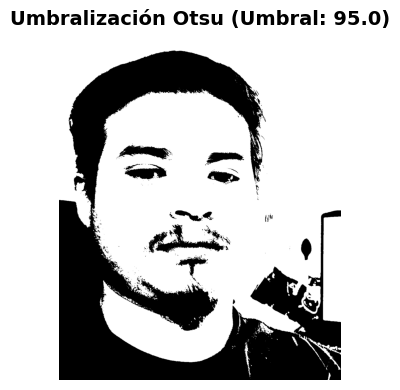

In [10]:
print("\n UMBRALIZACIÓN CON MÉTODO DE OTSU ")

# Aplicar umbralización de Otsu
umbral_otsu, thresh_otsu = cv2.threshold(
    gray,
    0,    # Umbral inicial (se ignora con Otsu)
    255,  # Valor máximo
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f"Umbral automático calculado por Otsu: {umbral_otsu}")
show_image(thresh_otsu, f"Umbralización Otsu (Umbral: {umbral_otsu:.1f})")